**Mood classification using CNN(Happy/Sad)**

In [ ]:
# !nvidia-smi
# Need GPU for this so ran in google collab

Thu Jul  9 08:35:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   64C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2
import os


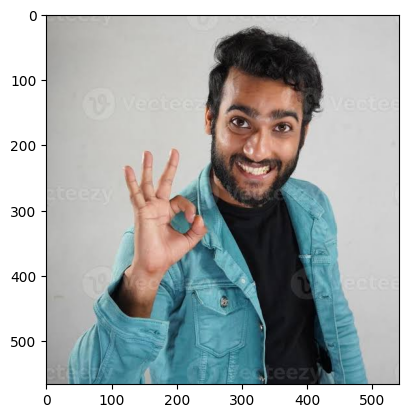

In [22]:
img = image.load_img('/content/drive/MyDrive/CNN- Happy or Sad/training/Happy/image1.jfif')

plt.imshow(img)


array([[[175, 179, 180],
        [165, 169, 170],
        [154, 158, 159],
        ...,
        [206, 206, 206],
        [206, 206, 206],
        [206, 206, 206]],

       [[172, 176, 177],
        [164, 168, 169],
        [154, 158, 159],
        ...,
        [206, 206, 206],
        [206, 206, 206],
        [206, 206, 206]],

       [[168, 172, 173],
        [162, 166, 167],
        [154, 158, 159],
        ...,
        [206, 206, 206],
        [206, 206, 206],
        [206, 206, 206]],

       ...,

       [[147, 147, 147],
        [147, 147, 147],
        [148, 148, 148],
        ...,
        [181, 181, 181],
        [183, 183, 183],
        [186, 186, 186]],

       [[146, 146, 146],
        [147, 147, 147],
        [147, 147, 147],
        ...,
        [180, 180, 180],
        [180, 180, 180],
        [182, 182, 182]],

       [[145, 145, 145],
        [145, 145, 145],
        [145, 145, 145],
        ...,
        [180, 180, 180],
        [179, 179, 179],
        [179, 179, 179]]], dtype=uint8)
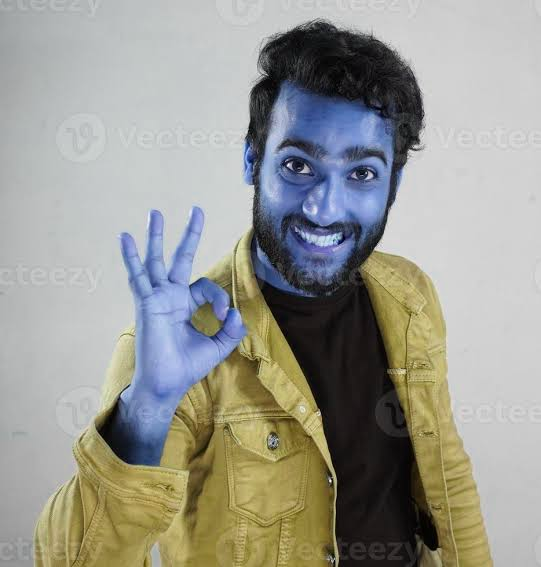

In [23]:
i1=cv2.imread('/content/drive/MyDrive/CNN- Happy or Sad/training/Happy/image1.jfif')
i1

In [24]:
i1.shape

(567, 541, 3)

In [25]:
train = ImageDataGenerator(rescale=1/200)
validation = ImageDataGenerator(rescale=1/200)

# to scale all the images i need to divide by 255
# we need to resize the image using 200,200 pixel

In [42]:
train_dataset= train.flow_from_directory('/content/drive/MyDrive/CNN- Happy or Sad/training',target_size=(200,200),batch_size=32,class_mode='binary')

validation_dataset = validation.flow_from_directory('/content/drive/MyDrive/CNN- Happy or Sad/validation',target_size=(200,200),batch_size=32,class_mode='binary')


Found 10 images belonging to 2 classes.
Found 4 images belonging to 2 classes.


In [28]:
train = ImageDataGenerator(rescale=1/255)
validation = ImageDataGenerator(rescale=1/255)

train_dataset = train.flow_from_directory(
    '/content/drive/MyDrive/CNN- Happy or Sad/training',
    target_size=(200,200),
    batch_size=32,
    class_mode='binary'
)

validation_dataset = validation.flow_from_directory(
    '/content/drive/MyDrive/CNN- Happy or Sad/validation',
    target_size=(200,200),
    batch_size=32,
    class_mode='binary'
)

Found 10 images belonging to 2 classes.
Found 4 images belonging to 3 classes.


In [29]:
train_dataset.class_indices

{'Happy': 0, 'sad': 1}

In [30]:
train_dataset.classes

array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1], dtype=int32)

In [12]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(200, 200, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    17,334,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,358,881 (66.22 MB)

 Trainable params: 17,358,881 (66.22 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    metrics=['accuracy']
)

In [52]:
model_fit=model.fit(train_dataset,
                   steps_per_epoch=3,
                   epochs=25,
                   validation_data=validation_dataset)

Epoch 1/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 1.0000 - loss: 0.1015 - val_accuracy: 1.0000 - val_loss: 0.1223
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.0842 - val_accuracy: 1.0000 - val_loss: 0.1226
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.0746 - val_accuracy: 1.0000 - val_loss: 0.0871
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 1.0000 - loss: 0.0727 - val_accuracy: 1.0000 - val_loss: 0.1107
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 1.0000 - loss: 0.0657 - val_accuracy: 1.0000 - val_loss: 0.0620
Epoch 6/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 1.0000 - loss: 0.0490 - val_accuracy: 1.0000 - val_loss: 0.0523
Epoch 7/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 1.0000 - loss: 0.0293 - val_accuracy: 1.0000 - val_loss: 0.0372
Epoch 8/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.0225 - val_accuracy: 1.0000 - val_loss: 0.0310


In [53]:
print("Training samples:", train_dataset.samples)
print("Validation samples:", validation_dataset.samples)

print("Training classes:", train_dataset.class_indices)
print("Validation classes:", validation_dataset.class_indices)

Training samples: 10
Validation samples: 4
Training classes: {'Happy': 0, 'sad': 1}
Validation classes: {'happy': 0, 'sad': 1}


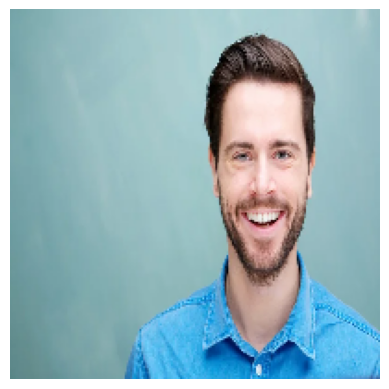

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Raw Prediction: [[0.46977517]]
{'Happy': 0, 'sad': 1}
😊 Prediction: Happy


In [54]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = image.load_img(
    '/content/drive/MyDrive/CNN- Happy or Sad/testing/image22.jpg',
    target_size=(200,200)
)

# Display image
plt.imshow(img)
plt.axis('off')
plt.show()

# Convert image to array
img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Normalize (same as training)
img_array = img_array / 255.0

# Predict
prediction = model.predict(img_array)

print("Raw Prediction:", prediction)

# Print class mapping
print(train_dataset.class_indices)

if prediction[0][0] < 0.5:
    print("😊 Prediction: Happy")
else:
    print("😢 Prediction: Sad")

In [55]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np

test_folder = "/content/drive/MyDrive/CNN- Happy or Sad/testing"

for file in os.listdir(test_folder):
    if file.lower().endswith((".png", ".jpg", ".jpeg")):

        img = image.load_img(
            os.path.join(test_folder, file),
            target_size=(200,200)
        )

        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array / 255.0

        prediction = model.predict(img_array, verbose=0)

        label = "😊 Happy" if prediction[0][0] < 0.5 else "😢 Sad"

        print(f"{file:20} --> {label} (Score: {prediction[0][0]:.4f})")

image22.jpg          --> 😊 Happy (Score: 0.4698)


In [ ]:
model.summary

NameError: name 'model' is not defined